# ML Problem Framing & Responsible Data Analysis
## Customer Churn Prediction

### Objective
Determine whether machine learning is justified for predicting customer churn before training a model.

### Decision
The proposed decision is whether a customer should be flagged for possible retention follow-up.

### Prediction Target
`churned`

- 0 = Customer did not churn
- 1 = Customer churned

### Unit of Observation
One row represents one customer.

### Action Window
The dataset does not specify the prediction horizon. Therefore, the exact action window must be defined before deployment.

### Non-ML Baseline
The majority-class baseline predicts "No Churn" (0) for every customer.

### Important Note
This notebook focuses on data quality assessment and the non-ML baseline. An ML model is not trained because the current dataset contains only 12 observations and is insufficient for reliable model development and evaluation.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer-churn-training.csv")

df.head()

,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12
Number of columns: 7


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        12 non-null     str  
 1   tenure_months      12 non-null     int64
 2   support_tickets    12 non-null     int64
 3   monthly_spend_inr  12 non-null     int64
 4   last_login_days    12 non-null     int64
 5   plan_type          12 non-null     str  
 6   churned            12 non-null     int64
dtypes: int64(5), str(2)
memory usage: 918.0 bytes


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
print("Churn distribution:")
print(df["churned"].value_counts())

Churn distribution:
churned
0    7
1    5
Name: count, dtype: int64


In [9]:
print("Churn percentage:")
print(df["churned"].value_counts(normalize=True) * 100)

Churn percentage:
churned
0    58.333333
1    41.666667
Name: proportion, dtype: float64


In [10]:
df.describe()

,tenure_months,support_tickets,monthly_spend_inr,last_login_days,churned
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,12.166667,2.250000,915.666667,10.000000,0.416667
std,9.242524,1.602555,332.574895,9.095453,0.514929
min,1.000000,0.000000,499.000000,1.000000,0.000000
25%,5.500000,1.000000,724.000000,2.750000,0.000000
50%,9.500000,2.000000,899.000000,7.000000,0.000000
75%,18.500000,3.250000,1074.000000,14.750000,1.000000
max,30.000000,5.000000,1499.000000,30.000000,1.000000


In [11]:
print("Plan type distribution:")
print(df["plan_type"].value_counts())

Plan type distribution:
plan_type
Basic       5
Standard    4
Pro         3
Name: count, dtype: int64


In [12]:
plan_churn = pd.crosstab(df["plan_type"], df["churned"])

print(plan_churn)

churned    0  1
plan_type      
Basic      0  5
Pro        3  0
Standard   4  0


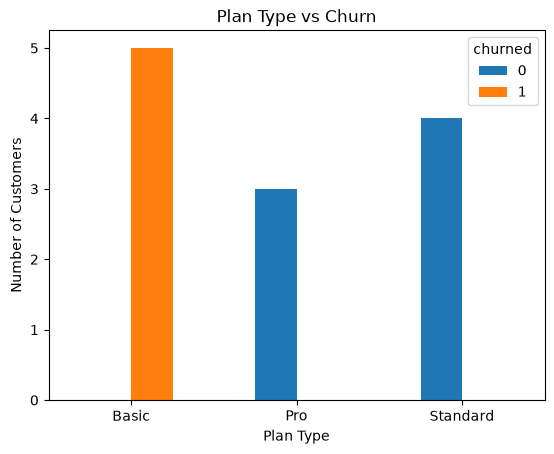

In [13]:
plan_churn.plot(kind="bar")

plt.title("Plan Type vs Churn")
plt.xlabel("Plan Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [14]:
y_actual = df["churned"]

# Majority-class baseline
y_baseline = np.zeros(len(df), dtype=int)

print("Actual values:")
print(y_actual.values)

print("\nBaseline predictions:")
print(y_baseline)

Actual values:
[1 0 1 0 0 1 0 1 0 1 0 0]

Baseline predictions:
[0 0 0 0 0 0 0 0 0 0 0 0]


In [15]:
accuracy = accuracy_score(y_actual, y_baseline)

precision = precision_score(
    y_actual,
    y_baseline,
    zero_division=0
)

recall = recall_score(
    y_actual,
    y_baseline,
    zero_division=0
)

f1 = f1_score(
    y_actual,
    y_baseline,
    zero_division=0
)

print("Baseline Performance")
print("--------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Baseline Performance
--------------------
Accuracy : 0.5833333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [16]:
cm = confusion_matrix(y_actual, y_baseline)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7 0]
 [5 0]]


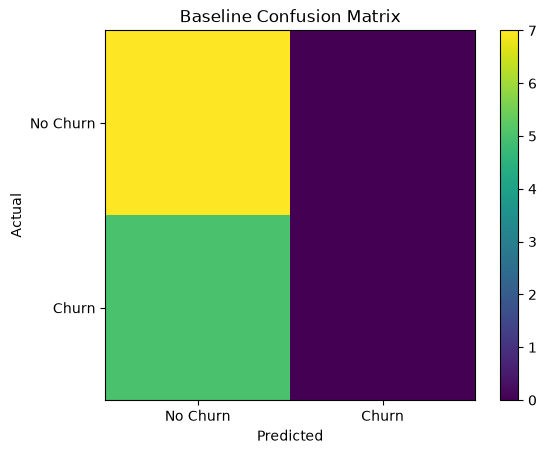

In [17]:
plt.imshow(cm)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

plt.show()

In [18]:
print("Total customer records:", len(df))
print("Unique customer IDs:", df["customer_id"].nunique())


Total customer records: 12
Unique customer IDs: 12


In [19]:
if df["customer_id"].nunique() == len(df):
    print("All customer IDs are unique.")
else:
    print("Duplicate customer IDs exist.")

All customer IDs are unique.


## Baseline Findings

1. The dataset contains only 12 customer records.

2. There are 5 churned customers and 7 non-churned customers.

3. The majority class is "No Churn" (0).

4. The majority-class baseline achieves approximately 58.3% accuracy.

5. However, the baseline has 0% recall for churned customers because it does not identify any churned customer.

6. Therefore, accuracy alone is not sufficient for evaluating a customer churn prediction system.

7. The current dataset is too small to establish reliable ML model performance.

## Conclusion

The non-ML majority-class baseline predicts every customer as non-churned.

Although this baseline achieves approximately 58.3% accuracy, it has 0% recall for churned customers. Therefore, it would fail to identify customers who actually churn.

The current dataset contains only 12 observations, including 5 churn cases. In addition, the prediction horizon, data provenance, consent or permission, and train/test separation are not documented.

Therefore, an ML model should not be considered production-ready using this dataset alone.

Before training an ML model, a larger and properly documented dataset should be collected. The prediction window, feature cutoff, false-positive and false-negative costs, validation strategy, human-review process, monitoring conditions, and rollback conditions should also be defined.